In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from sklearn import model_selection, metrics
from glob import glob
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import munch
import yaml

In [3]:
plt.style.use('default')

# Utils

In [4]:
def read_yaml(fname: str)-> munch.Munch:


    with open(fname) as fobj:
        config = yaml.safe_load(fobj)
        
    #config = munch.munchify(config)

    return config

# Imports

In [5]:
url = "https://data.up.ethz.ch/shared/OceanSODA-ETHZv2/total_alkalinity/GLODAPv2023/GLODAPv2023-raw_collocated-{y}.pq"
df = pd.concat([pd.read_parquet(url.format(y=y)) for y in range(1982, 2022)])

renaming_dict = read_yaml('/home/edupuis/highres_TA/renaming_dict.yaml')
df = df.rename(columns = renaming_dict)

# move talk column to the front
col = df.pop('talk_gp')
df.insert(0, 'talk_gp', col)

# store column names       
all_cols = df.columns.to_list()

all_time_cols = [i for i in all_cols if 'time' in i]
all_coord_cols = [i for i in all_cols if ('lat' in i or 'lon' in i or 'time' in i)]

# print info
df.info()

<class 'pandas.DataFrame'>
Index: 42134 entries, 83 to 492
Data columns (total 62 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   talk_gp                42134 non-null  float64       
 1   expocode_gp            42134 non-null  str           
 2   time_gp                42134 non-null  datetime64[ns]
 3   lat_gp                 42134 non-null  float64       
 4   lon_gp                 42134 non-null  float64       
 5   bottomdepth_gp         42134 non-null  float64       
 6   maxsampdepth_gp        41978 non-null  float64       
 7   depth_gp               42134 non-null  float64       
 8   temp_gp                41938 non-null  float64       
 9   salinity_gp            41650 non-null  float64       
 10  oxygen_gp              37673 non-null  float64       
 11  aou_gp                 37037 non-null  float64       
 12  nitrate_gp             34351 non-null  float64       
 13  nitrite_gp        

In [6]:
salinity_bin_edges = [0, 32, 34, 36, np.inf]
salinity_bin_labels = ['<32', '32-34', '34-36', '>36']
df['salinity_bin'] = pd.cut(df['salinity_gp'], bins=salinity_bin_edges, labels=salinity_bin_labels)

df = df.dropna(subset=['salinity_bin'])

In [7]:
print(df.talk_flag_gp.unique())
print(df.talk_qc_gp.unique())

[2. 0.]
[0. 1.]


# Train-test split

In [ ]:
def plot_split(source_df, train_idx, test_idx, label_train = 'train', label_eval = 'test', train_color = "C0", eval_color = "C1"):

    train_expo = set(source_df.expocode_gp.iloc[train_idx].unique())
    test_expo = set(source_df.expocode_gp.iloc[test_idx].unique())
    assert len(train_expo & test_expo) == 0, "can't have overlapping expocodes in train and test sets"

    source_df.iloc[train_idx].expocode_gp.value_counts().plot(kind='hist', bins=50, alpha=0.5, label= label_train)
    source_df.iloc[test_idx].expocode_gp.value_counts().plot(kind='hist', bins=50, alpha=0.5, label=label_eval)
    plt.legend()

    split_stats = pd.concat([
        source_df['salinity_bin'].iloc[train_idx].value_counts()[salinity_bin_labels],
        source_df['salinity_bin'].iloc[test_idx].value_counts()[salinity_bin_labels], 
    ], axis=1, keys=[label_train, label_eval])

    fig, ax = plt.subplots(figsize=[12, 5])
    source_df.iloc[train_idx].plot(x='lon_gp', y='lat_gp', c=train_color, kind='scatter', alpha=0.5, label=label_train, ax=ax)
    source_df.iloc[test_idx].plot(x='lon_gp', y='lat_gp', c=eval_color, kind='scatter', alpha=0.5, label=label_eval, ax=ax)
    ax.legend()
    
    split_stats
    
    plt.show();


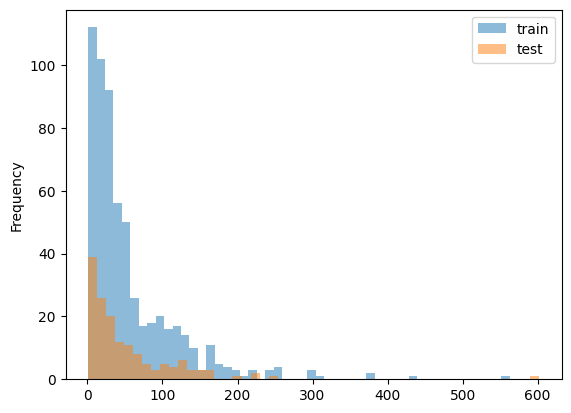

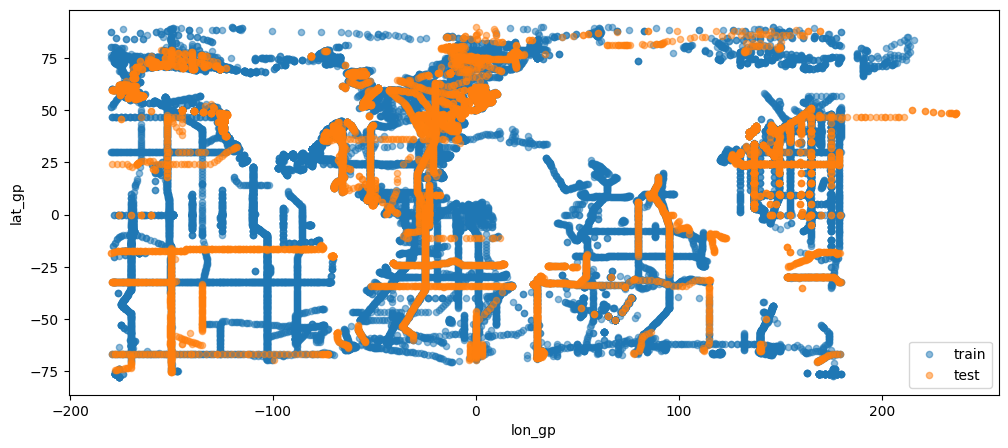

In [ ]:
splitter = model_selection.StratifiedGroupKFold(n_splits=5)
splits = splitter.split(X= df, y = df['salinity_bin'], groups=df["expocode_gp"])

train_idx, test_idx = next(splits)

train_split = df.iloc[train_idx]
test_split = df.iloc[test_idx]

plot_split(source_df=df,train_idx=train_idx,test_idx=test_idx)


#clean up to useful predictors only

drop_cols = (
    ['talk_gp', 'year_gp', 'expocode_gp', 'salinity_bin', 'tco2_gp', 'fco2_gp', 'silicate_gp', 'phtsinsitutp_gp', 'oxygen_gp', 'nitrate_gp', 'nitrite_gp', 'phosphate_gp',  'aou_gp', 'salinity_soda','temp_soda'] 
    + df.filter(regex='time').columns.tolist() 
    + df.filter(regex='lat|lon').columns.tolist() 
    + df.filter(regex='uncert|error').columns.tolist()
    + df.filter(regex='depth').columns.tolist()
    + df.filter(regex='sss').columns.tolist()
    + df.filter(regex='flag').columns.tolist()
    + df.filter(regex='qc').columns.tolist()
)

x_train = train_split.drop(columns=drop_cols)
y_train = train_split['talk_gp']

x_test = test_split.drop(columns=drop_cols)
y_test = test_split['talk_gp']

x_train.columns

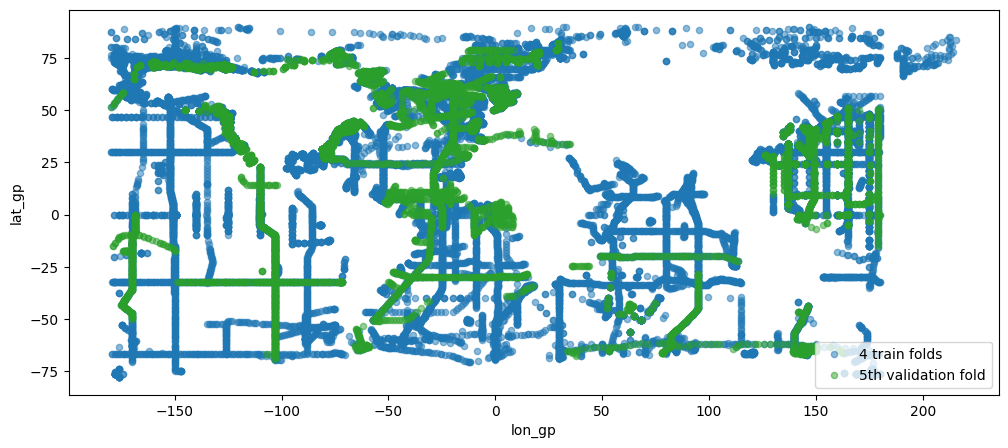

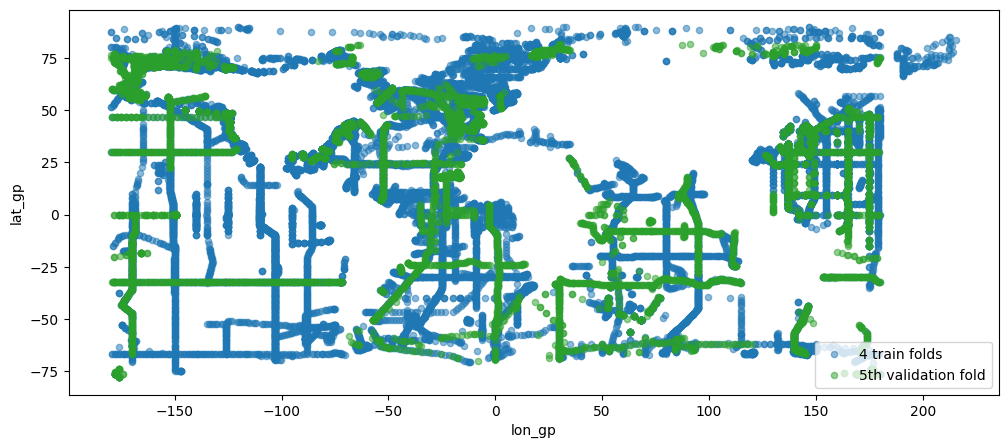

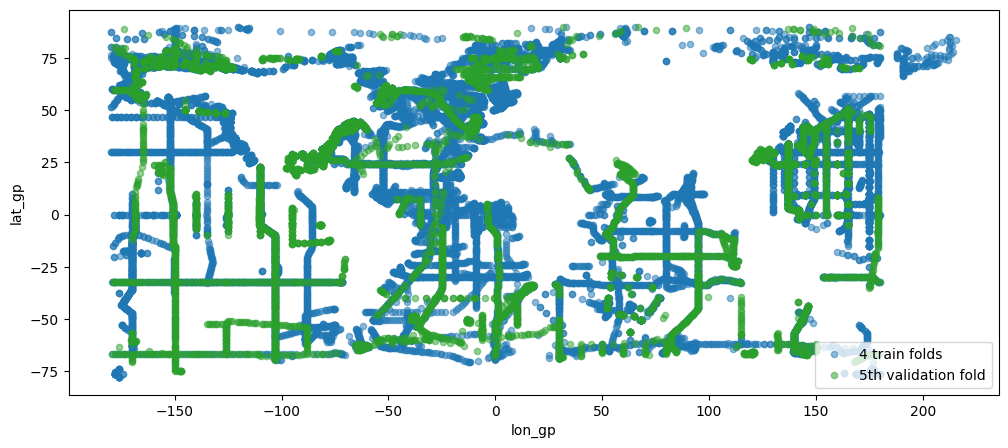

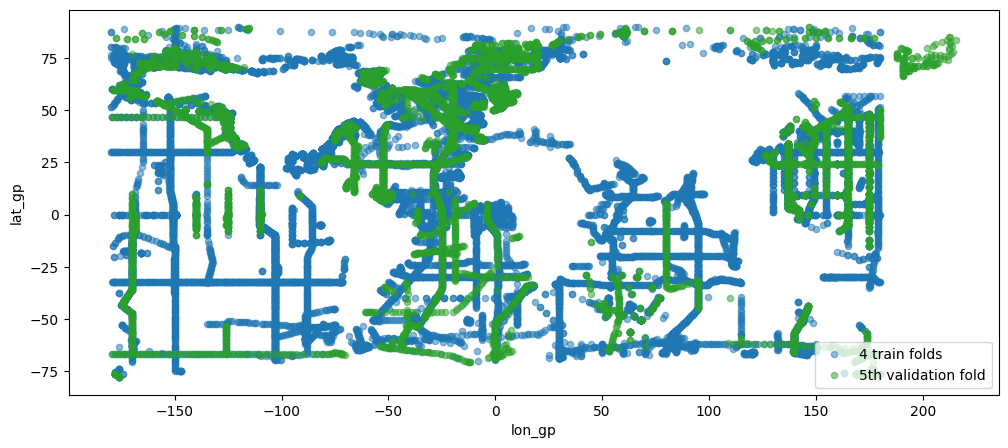

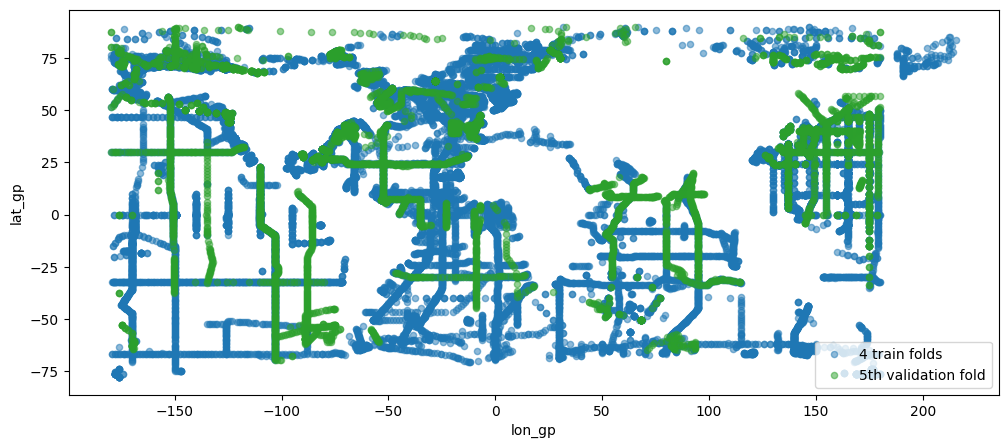

In [ ]:
# Cross validation folds:

cv_splitter = model_selection.StratifiedGroupKFold(n_splits=5)
cv_splits = list(cv_splitter.split(train_split, train_split['salinity_bin'], groups=train_split["expocode_gp"]))


for a_cv_split in cv_splits:
    
    # fig, ax = plt.subplots(figsize=[12, 5])

    train_folds_idx, val_fold_idx = a_cv_split
    
    plot_split(train_split, train_folds_idx, val_fold_idx, label_train='train folds (4/5)', label_eval='validation fold (1/5)', eval_color="C2")
    
    

    # # Ensure the selections return DataFrames and specify x and y columns explicitly
    # train_split.iloc[train_folds_idx].plot.scatter(
    #     x='lon_gp', y='lat_gp', c="C0", alpha=0.5, label='4 train folds', ax=ax
    # )
    # train_split.iloc[val_fold_ix].plot.scatter(
    #     x='lon_gp', y='lat_gp', c="C2", alpha=0.5, label='5th validation fold', ax=ax
    # )
    
    
    # folds_stats = pd.concat([
    # salinity_classifier.iloc[train_idx].iloc[train_folds_idx].value_counts()[salinity_bin_labels],
    # salinity_classifier.iloc[train_idx].iloc[val_fold_ix].value_counts()[salinity_bin_labels], 
    # ], axis=1, keys=['train folds (4)', 'validation fold (1)'])
    # ax.legend()
    
    # folds_stats
    
    # plt.show()





Index(['temp_gp', 'salinity_gp', 'mld_soda', 'sst_cciT', 'ice_cciT',
       'ssh_adt_cmems', 'ssh_sla_cmems', 'mld_glorys', 'chl_globcolour'],
      dtype='str')

In [ ]:
# # save train-test split to files
# x_train.to_parquet("X_train.parquet")
# x_test.to_parquet("X_test.parquet")
# y_train.to_parquet("y_train.parquet")
# y_test.to_parquet("y_test.parquet")

Index(['temp_gp', 'salinity_gp', 'mld_soda', 'sst_cciT', 'ice_cciT',
       'ssh_adt_cmems', 'ssh_sla_cmems', 'mld_glorys', 'chl_globcolour'],
      dtype='str')

# CatBoost

In [ ]:
import catboost as cb

train_pool = cb.Pool(data =x_train, label= y_train )
test_pool = cb.Pool(data = x_test, label =y_test)

baseline (no CV, no tuning, tested on test set)

In [29]:
# Fit the CatBoost model with eval_set
RMSE_model = cb.CatBoostRegressor(iterations=10)
RMSE_model.fit(train_pool, eval_set=test_pool, logging_level='Info', plot=True)

# can also be used for categorical features with cat_features = []



MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.5

salinity_gp, bin=17 score 15787.87454
salinity_gp, bin=154 score 17960.42569
salinity_gp, bin=0 score 18607.71381
salinity_gp, bin=51 score 19354.52666
salinity_gp, bin=227 score 19632.26822
salinity_gp, bin=7 score 20097.08115
0:	learn: 71.8497644	test: 64.2709128	best: 64.2709128 (0)	total: 75.5ms	remaining: 679ms

salinity_gp, bin=35 score 8132.182074
salinity_gp, bin=179 score 9032.283116
salinity_gp, bin=11 score 9849.35632
salinity_gp, bin=2 score 10156.55596
mld_glorys, bin=36 score 10344.0996
sst_cciT, bin=224 score 10576.81067
1:	learn: 52.3204502	test: 48.0344529	best: 48.0344529 (1)	total: 84.6ms	remaining: 339ms

salinity_gp, bin=72 score 4801.52635
salinity_gp, bin=14 score 5331.589352
salinity_gp, bin=239 score 5702.479661
ssh_adt_cmems, bin=146 score 5918.611567
temp_gp, bin=219 score 6066.74734
salinity_gp, bin=1 score 6233.430137
2:	learn: 43.2831045	test: 41.2654231	best: 41.2654231 (2)	total: 92.8ms	remaining: 216ms

salinity_gp, bin=64 scor

CatBoostRegressor(iterations=10, loss_function='RMSE')

In [30]:

uncertRMSE_model = cb.CatBoostRegressor(iterations=10, loss_function='RMSEWithUncertainty')
uncertRMSE_model.fit(train_pool, eval_set=test_pool , logging_level='Info', plot=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))


salinity_gp, bin=17 score 15793.421
salinity_gp, bin=154 score 17965.13835
salinity_gp, bin=0 score 18618.49626
salinity_gp, bin=51 score 19365.0428
salinity_gp, bin=227 score 19642.6394
salinity_gp, bin=7 score 20107.96616
0:	learn: 6.0928732	test: 5.9993174	best: 5.9993174 (0)	total: 21.2ms	remaining: 191ms

salinity_gp, bin=18 score 15081.93463
salinity_gp, bin=146 score 17204.01523
salinity_gp, bin=0 score 18020.91465
salinity_gp, bin=55 score 18793.39357
mld_glorys, bin=41 score 19088.17668
salinity_gp, bin=213 score 19365.92546
1:	learn: 6.0085026	test: 5.9304743	best: 5.9304743 (1)	total: 32.4ms	remaining: 130ms

salinity_gp, bin=18 score 14697.63247
salinity_gp, bin=167 score 16822.80917
salinity_gp, bin=62 score 17575.94488
salinity_gp, bin=1 score 18116.70712
ice_cciT, bin=30 score 18486.05155
salinity_gp, bin=228 score 18441.89196
2:	learn: 5.9362415	test: 5.8711579	best: 5.8711579 (2)	total: 44.2ms	remaining: 103ms

salinity_gp, bin=16 score 14218.65298
salinity_gp, bin=13

CatBoostRegressor(iterations=10, loss_function='RMSEWithUncertainty')

In [ ]:
yhat_train = model.predict(x_train)
yhat_test = model.predict(x_test)

In [ ]:
RMSE = model.eval_metrics(x_train,'RMSE')

In [ ]:
df_metrics = pd.DataFrame({
    'r2_score': {
        'train': metrics.r2_score(y_train, yhat_train), 
        'test': metrics.r2_score(y_test, yhat_test)
    },
    'rmse': {
        'train': metrics.root_mean_squared_error(y_train, yhat_train), 
        'test': metrics.root_mean_squared_error(y_test, yhat_test)
    },
    'mae': {
        'train': metrics.mean_absolute_error(y_train, yhat_train), 
        'test': metrics.mean_absolute_error(y_test, yhat_test)
    },
    'bias': {
        'train': (yhat_train - y_train).mean(), 
        'test': (yhat_test - y_test).mean()
    }
})

df_metrics.T.round(2)

In [ ]:
names: list[str] = model.feature_names_  # type: ignore
values = model.feature_importances_

pd.Series({k: float(v) for k, v in zip(names, values, strict=True)}).sort_values(ascending=False)

With QC based sample weighting

In [ ]:
# sample_weights = something with qc or flags
# weigthed_train_pool = cb.Pool( x_train, y_train, weights = sample_weights)
# weigthed_test_pool = cb.Pool(x_test, y_test)

with cross validation

In [31]:
# Extract the first validation split from cv_splits
cv_folds = dict()

for i, (train_folds_idx, eval_fold_idx) in enumerate(cv_splits):
    
    
    # Create the eval_set using the validation data
    train_folds_pool = cb.Pool(data = x_train.iloc[train_folds_idx], label = y_train.iloc[train_folds_idx])
    eval_fold_pool = cb.Pool(data = x_train.iloc[eval_fold_idx], label = y_train.iloc[eval_fold_idx])
    
    cv_folds[f"fold{i}"] = {
        'train_pool': train_folds_pool,
        'eval_pool': eval_fold_pool,
        'train_idx': train_folds_idx,
        'eval_idx': eval_fold_idx
    }



CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=1]="35MF19820626": Cannot convert '35MF19820626' to float

In [ ]:
# #store pools in a list
# cv_pools_list = [tuple([train_folds_pool,eval_fold_pool])]

RMSE_model.fit(train_folds_pool, eval_set=eval_fold_pool)
RMSEpreds = RMSE_model.predict(eval_fold_pool)
RMSE_scores = RMSE_model.get_best_score()



uncertRMSE_rmse = np.sqrt(((uncertRMSEpreds - y[eval_fold_idx])**2).mean())
RMSE_rmse = np.sqrt(((RMSEpreds - y[eval_fold_idx])**2).mean())

["validation"]["RMSE"]
scores.append(score)


scores_RMSE_model.append(rmse)
scores_uncertRMSE_model.append(rmse)

print("CV RMSE:", np.mean(scores))
    
    # Create the eval_set using the validation data
    train_folds_pool = cb.Pool(data = x_train.iloc[train_folds_idx], label = y_train.iloc[train_folds_idx])
    eval_fold_pool = cb.Pool(data = x_train.iloc[eval_fold_idx], label = y_train.iloc[eval_fold_idx])   
    
    uncertRMSE_model.fit(train_folds_pool, eval_set=eval_fold_pool)
    uncertRMSEpreds = uncertRMSE_model.predict(eval_fold_pool)
    uncertRMSE_scores = uncertRMSE_model.get_best_score()

In [ ]:






cv_results = []

for fold, (train_indices, val_indices) in enumerate(cv_splits):
    print(f"Training on fold {fold + 1}/{len(cv_splits)}")
    
    # Split the data into training and validation sets
    X_train_fold = x_train.iloc[train_indices]
    y_train_fold = y_train.iloc[train_indices]
    X_val_fold = x_train.iloc[val_indices]
    y_val_fold = y_train.iloc[val_indices]
    
    # Create the CatBoost model
    model = cb.CatBoostRegressor(iterations=10_000, logging_level='Info')
    
    # Fit the model on the current fold
    model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], plot=True)
    
    # Evaluate the model on the validation set
    y_val_pred = model.predict(X_val_fold)
    fold_metrics = {
        'fold': fold + 1,
        'r2_score': metrics.r2_score(y_val_fold, y_val_pred),
        'rmse': metrics.mean_squared_error(y_val_fold, y_val_pred, squared=False),
        'mae': metrics.mean_absolute_error(y_val_fold, y_val_pred)
    }
    cv_results.append(fold_metrics)

# Display cross-validation results
cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)
print("Average Metrics:")
print(cv_results_df.mean(numeric_only=True))